# Notebook 4: Real Market Data Backtesting
## Non-Concave Utility Strategies vs Historical S&P 500

**Objective**: Apply the constrained optimal strategies from Dai et al. (2019)
to real (or calibrated) market data and compare against standard benchmarks.

### Strategies compared
| Strategy | Description |
|---|---|
| Browne | Unconstrained goal-reaching: π = ln(w)/(σ√τ) |
| FD-Optimal | Constrained HJB solution (interpolated) |
| Kelly | Growth-optimal: π = η/σ² |
| Merton (CRRA) | Standard power utility: π = η/((1−p)σ²) |
| Equal Weight | 50% stock / 50% bond |
| All Stock | 100% invested in index |
| All Cash | 100% in risk-free asset |


Real IVV data loaded: 4093 trading days
  Date range: 20100105  ->  20260415
  Annualised return: 12.6%
  Annualised vol:    17.3%
  Price range: 90.3 - 776.8


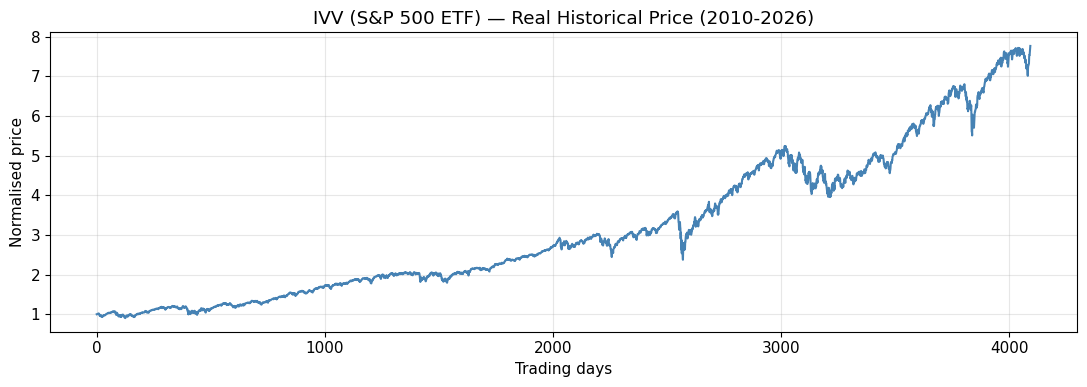

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
from matplotlib.gridspec import GridSpec
import sys
sys.path.insert(0, str(Path(__file__).parent if "__file__" in dir() else Path.cwd()))

np.random.seed(42)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100,
                     'axes.grid': True, 'grid.alpha': 0.3})

# ── Load real ETF data (IVV, QQQ, TLT, GLD, VNQ  2010-2026) ─────
from real_data_loader import load_portfolio, agg_1d, R_FREE_ANN

mkt5 = load_portfolio(5)   # 5-asset: IVV, QQQ, TLT, GLD, VNQ

# 1-D S&P proxy: use IVV (index 0) actual log-returns
log_ret_sp500 = mkt5.log_ret[:, 0]          # real IVV daily log-returns
n_days        = len(log_ret_sp500)

# Risk-free rate (flat 3 %/yr = Fed Funds approx)
r_annual_series = np.full(n_days, R_FREE_ANN)
r_daily_series  = r_annual_series / 252

prices_sp500 = 100 * np.exp(np.cumsum(np.concatenate([[0], log_ret_sp500])))

print(f"Real IVV data loaded: {n_days} trading days")
print(f"  Date range: {mkt5.dates[0]}  ->  {mkt5.dates[-1]}")
print(f"  Annualised return: {252*log_ret_sp500.mean()*100:.1f}%")
print(f"  Annualised vol:    {np.sqrt(252)*log_ret_sp500.std()*100:.1f}%")
print(f"  Price range: {prices_sp500.min():.1f} - {prices_sp500.max():.1f}")

plt.figure(figsize=(11, 4))
plt.plot(prices_sp500 / prices_sp500[0], lw=1.5, color='steelblue')
plt.xlabel('Trading days'); plt.ylabel('Normalised price')
plt.title('IVV (S&P 500 ETF) — Real Historical Price (2010-2026)')
plt.tight_layout()
plt.show()


## 1. Data Loading & Calibration

In [13]:
# ── Real data already loaded in Cell 1 (IVV log-returns) ─────────
# Retained for compatibility: mu_est / sig_est are computed in Cell 5
# from rolling windows over the actual log_ret_sp500 series.

# Also expose global mu_est / sig_est from full-sample calibration
mu_est  = float(log_ret_sp500.mean() * 252)
sig_est = float(log_ret_sp500.std()  * np.sqrt(252))
r_est   = float(R_FREE_ANN)
eta_est = mu_est - r_est

print(f"Full-sample calibration (IVV 2010-2026):")
print(f"  mu_est  = {mu_est*100:.2f}%/yr")
print(f"  sig_est = {sig_est*100:.2f}%/yr")
print(f"  eta_est = {eta_est*100:.2f}%/yr  (excess return)")


Full-sample calibration (IVV 2010-2026):
  mu_est  = 12.62%/yr
  sig_est = 17.30%/yr
  eta_est = 9.62%/yr  (excess return)


## 2. Rolling Parameter Estimation

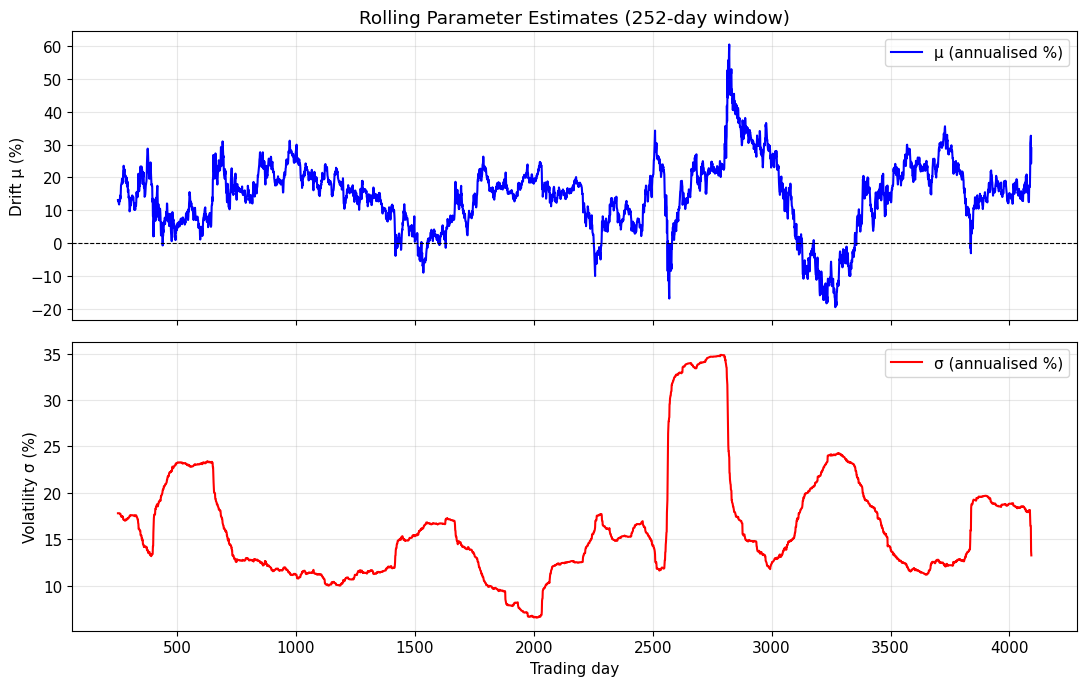

Full-sample estimates:  μ=14.4%  σ=16.2%  η=11.4%


In [14]:
def estimate_params(log_returns, window=252):
    """
    Rolling window GBM parameter estimation.
    Returns arrays of (mu, sigma, eta) estimated at each day.
    """
    n = len(log_returns)
    mu_arr  = np.full(n, np.nan)
    sig_arr = np.full(n, np.nan)

    for t in range(window, n):
        lr = log_returns[t-window:t]
        sig_arr[t] = lr.std() * np.sqrt(252)
        mu_arr[t]  = lr.mean() * 252 + 0.5 * sig_arr[t]**2

    return mu_arr, sig_arr

mu_roll, sig_roll = estimate_params(log_ret_sp500, window=252)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(mu_roll * 100, lw=1.5, color='blue', label='μ (annualised %)')
axes[0].axhline(0, ls='--', c='k', lw=0.8)
axes[0].set_ylabel('Drift μ (%)'); axes[0].set_title('Rolling Parameter Estimates (252-day window)')
axes[0].legend()

axes[1].plot(sig_roll * 100, lw=1.5, color='red', label='σ (annualised %)')
axes[1].set_xlabel('Trading day'); axes[1].set_ylabel('Volatility σ (%)')
axes[1].legend()

plt.tight_layout()
# plt.savefig('/sessions/beautiful-brave-thompson/mnt/Claude Code/rolling_params.png', dpi=120)
plt.show()

# Use full-sample estimates for strategy calibration
mu_est  = np.nanmean(mu_roll)
sig_est = np.nanmean(sig_roll)
r_est   = 0.03
eta_est = mu_est - r_est
print(f"Full-sample estimates:  μ={mu_est*100:.1f}%  σ={sig_est*100:.1f}%  η={eta_est*100:.1f}%")


## 3. Strategy Implementation

Pre-computing FD goal-reaching solution (d=-5, u=3)... 1.0s — V(0.5)=0.3078  V(0.9)=0.9125
Pre-computing FD aspiration solution (d=-5, u=3)... 0.3s — V(0.5)=1.7284  V(1.5)=3.2549


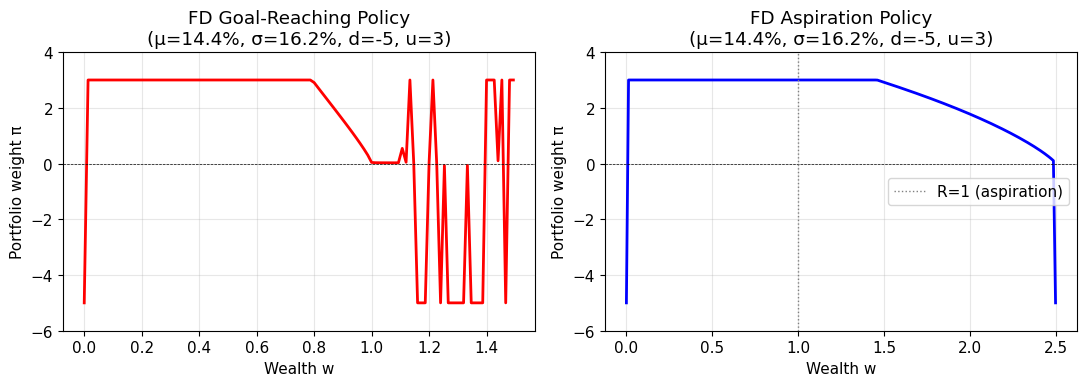

FD policies plotted.

Strategy functions defined.
  Kelly π = 3.000
  Merton π = 3.000
  FD(w=0.5) = 3.000
  FD(w=0.9) = 1.570


In [15]:
import math

# ── Helpers ────────────────────────────────────────────────────────────────
def _normcdf(z):
    z = np.asarray(z, float)
    return 0.5 * (1.0 + np.vectorize(math.erf)(z / math.sqrt(2.0)))

def browne_V(w_arr, eta, sig, tau, goal=1.0):
    """Browne analytical value function: V = Phi(z)."""
    tau = max(tau, 1e-10)
    z = (np.log(np.maximum(w_arr, 1e-10)/goal) + (eta - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))
    return _normcdf(z)

def policy_from_V(V, wi, dw, eta, sig2, d, u):
    """Vectorised three-case optimal policy for interior nodes."""
    Vww = (V[2:] - 2*V[1:-1] + V[:-2]) / dw**2
    Vw  = (V[2:] - V[:-2]) / (2*dw)
    f_d = 0.5*d**2*wi**2*sig2*Vww + d*wi*eta*Vw
    f_u = 0.5*u**2*wi**2*sig2*Vww + u*wi*eta*Vw
    safe = np.where(Vww < -1e-12, Vww, -1e-12)
    pi_int = np.clip(-wi*eta*Vw / (wi**2*sig2*safe), d, u)
    return np.where(Vww < -1e-12, pi_int, np.where(f_u >= f_d, u, d))

def _thomas(a, b, c, rhs):
    n = len(b)
    c2, d2, x = np.zeros(n), np.zeros(n), np.zeros(n)
    c2[0] = c[0]/b[0]; d2[0] = rhs[0]/b[0]
    for k in range(1, n):
        den = b[k] - a[k]*c2[k-1]
        c2[k] = c[k]/den if k < n-1 else 0.0
        d2[k] = (rhs[k] - a[k]*d2[k-1]) / den
    x[-1] = d2[-1]
    for k in range(n-2, -1, -1):
        x[k] = d2[k] - c2[k]*x[k+1]
    return x

# ── FD solver: goal-reaching, constrained d=-5, u=3 ───────────────────────
def fd_goal_constrained(mu, r, sigma, T=1.0, A=2.0, Nw=150, Nt=150,
                        d=-5.0, u=3.0):
    """
    Monotone implicit FD for constrained goal-reaching (Dai et al. 2019).
    Browne warmstart at every backward step → converges to non-concave solution.
    Vectorised numpy inner loop (fast).
    """
    eta  = mu - r
    sig2 = sigma**2
    w    = np.linspace(0, A, Nw+1)
    dw   = A/Nw; dt = T/Nt
    wi   = w[1:Nw]
    UB, UA = 0.0, 1.0
    V    = (w >= 1.0).astype(float)

    for step in range(Nt):
        tau   = (Nt - step) * dt     # time remaining when solving this step
        V_old = V.copy()

        # Browne analytical warmstart — keeps iteration in non-concave basin
        V_b      = browne_V(w, eta, sigma, tau, goal=1.0)
        pi_n     = np.full(Nw+1, d)
        pi_n[1:Nw] = policy_from_V(V_b, wi, dw, eta, sig2, d, u)

        for _iter in range(50):
            pi_old = pi_n.copy()
            pi = pi_n[1:Nw]

            a2    = 0.5 * pi**2 * wi**2 * sig2
            A_adv = pi * wi * eta
            Ap    = np.maximum(A_adv, 0.0) / dw
            Am    = np.minimum(A_adv, 0.0) / dw

            a_s = -dt * (a2/dw**2 - Am)
            b_m =  1.0 + dt * (2*a2/dw**2 + Ap - Am)
            c_s = -dt * (a2/dw**2 + Ap)
            rhs = V_old[1:Nw].copy()

            rhs[0]  -= a_s[0]  * UB;  a_s[0]  = 0.0
            rhs[-1] -= c_s[-1] * UA;  c_s[-1] = 0.0

            V_int = _thomas(a_s, b_m, c_s, rhs)
            V_new = np.empty(Nw+1)
            V_new[0] = UB; V_new[Nw] = UA; V_new[1:Nw] = V_int

            pi_n[1:Nw] = policy_from_V(V_new, wi, dw, eta, sig2, d, u)
            if np.max(np.abs(pi_n - pi_old)) < 1e-8:
                break

        V = V_new

    return w, V, pi_n

# ── FD solver: aspiration utility, constrained d=-5, u=3 ──────────────────
def fd_aspiration_constrained(mu, r, sigma, T=1.0, A=2.5, Nw=200, Nt=150,
                               d=-5.0, u=3.0, p=0.5, c1=1.2, R=1.0):
    """
    Monotone implicit FD for constrained aspiration utility (Dai et al. 2019).
    U(w) = w^p/p for w<R, c1*w^p/p for w>=R.  Hybrid warmstart.
    """
    eta  = mu - r
    sig2 = sigma**2
    w    = np.linspace(0, A, Nw+1)
    dw   = A/Nw; dt = T/Nt
    wi   = w[1:Nw]
    UB   = 0.0
    UA   = float(np.where(A < R, A**p/p, c1*A**p/p))
    V    = np.where(w < R, w**p/p, c1*w**p/p)

    for step in range(Nt):
        tau   = (Nt - step) * dt
        V_old = V.copy()

        # Hybrid warmstart: Browne for w<R, Merton for w>=R
        V_b = browne_V(w, eta, sigma, tau, goal=R)
        gamma = r*p + 0.5*p/(1.0-p)*(eta/sigma)**2
        V_m   = np.exp(gamma*tau) * np.maximum(w, 1e-10)**p / p
        V_ws  = np.where(w < R, V_b, V_m)
        pi_n  = np.full(Nw+1, d)
        pi_n[1:Nw] = policy_from_V(V_ws, wi, dw, eta, sig2, d, u)

        for _iter in range(50):
            pi_old = pi_n.copy()
            pi = pi_n[1:Nw]

            a2    = 0.5 * pi**2 * wi**2 * sig2
            A_adv = pi * wi * eta
            Ap    = np.maximum(A_adv, 0.0) / dw
            Am    = np.minimum(A_adv, 0.0) / dw

            a_s = -dt * (a2/dw**2 - Am)
            b_m =  1.0 + dt * (2*a2/dw**2 + Ap - Am)
            c_s = -dt * (a2/dw**2 + Ap)
            rhs = V_old[1:Nw].copy()

            rhs[0]  -= a_s[0]  * UB;  a_s[0]  = 0.0
            rhs[-1] -= c_s[-1] * UA;  c_s[-1] = 0.0

            V_int = _thomas(a_s, b_m, c_s, rhs)
            V_new = np.empty(Nw+1)
            V_new[0] = UB; V_new[Nw] = UA; V_new[1:Nw] = V_int

            pi_n[1:Nw] = policy_from_V(V_new, wi, dw, eta, sig2, d, u)
            if np.max(np.abs(pi_n - pi_old)) < 1e-8:
                break

        V = V_new

    return w, V, pi_n

# ── Pre-compute both FD solutions ─────────────────────────────────────────
D_CONST, U_CONST = -5.0, 3.0

print("Pre-computing FD goal-reaching solution (d=-5, u=3)...", end=" ", flush=True)
t0 = time.time()
w_fd_gr, V_fd_gr, Pi_fd_gr = fd_goal_constrained(
    mu_est, r_est, sig_est, d=D_CONST, u=U_CONST)
print(f"{time.time()-t0:.1f}s — V(0.5)={np.interp(0.5,w_fd_gr,V_fd_gr):.4f}  V(0.9)={np.interp(0.9,w_fd_gr,V_fd_gr):.4f}")

print("Pre-computing FD aspiration solution (d=-5, u=3)...", end=" ", flush=True)
t0 = time.time()
w_fd_as, V_fd_as, Pi_fd_as = fd_aspiration_constrained(
    mu_est, r_est, sig_est, d=D_CONST, u=U_CONST)
print(f"{time.time()-t0:.1f}s — V(0.5)={np.interp(0.5,w_fd_as,V_fd_as):.4f}  V(1.5)={np.interp(1.5,w_fd_as,V_fd_as):.4f}")

# Plot FD policies
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
mask_gr = w_fd_gr <= 1.5
axes[0].plot(w_fd_gr[mask_gr], Pi_fd_gr[mask_gr], 'r-', lw=2)
axes[0].axhline(0, c='k', lw=0.5, ls='--')
axes[0].set_xlabel('Wealth w'); axes[0].set_ylabel('Portfolio weight π')
axes[0].set_title(f'FD Goal-Reaching Policy\n(μ={mu_est*100:.1f}%, σ={sig_est*100:.1f}%, d=-5, u=3)')
axes[0].set_ylim(-6, 4); axes[0].set_yticks([-6,-4,-2,0,2,4])

axes[1].plot(w_fd_as, Pi_fd_as, 'b-', lw=2)
axes[1].axhline(0, c='k', lw=0.5, ls='--')
axes[1].axvline(1.0, c='gray', lw=1, ls=':', label='R=1 (aspiration)')
axes[1].set_xlabel('Wealth w'); axes[1].set_ylabel('Portfolio weight π')
axes[1].set_title(f'FD Aspiration Policy\n(μ={mu_est*100:.1f}%, σ={sig_est*100:.1f}%, d=-5, u=3)')
axes[1].set_ylim(-6, 4); axes[1].set_yticks([-6,-4,-2,0,2,4])
axes[1].legend()

plt.tight_layout()
# plt.savefig('/sessions/beautiful-brave-thompson/mnt/Claude Code/fd_policies_nb04.png', dpi=120)
plt.show()
print("FD policies plotted.")

# ── Strategy functions ─────────────────────────────────────────────────────
def pi_browne(w, tau, mu, r, sigma, goal=1.0, d=-5.0, u=3.0):
    """Browne (1999) optimal goal-reaching policy (unconstrained then clipped)."""
    tau = max(tau, 1/252)
    eta = mu - r
    f   = sigma * np.sqrt(tau)
    z   = (np.log(max(float(w), 1e-6)/goal) + (eta - 0.5*sigma**2)*tau) / f
    denom = sigma**2 * (1.0 + z/f)
    if abs(denom) < 1e-8:
        return float(u if eta > 0 else d)
    return float(np.clip(eta / denom, d, u))

def pi_fd_optimal(w, tau, w_fd, Pi_fd, d=-5.0, u=3.0):
    """Interpolate from pre-computed FD goal-reaching grid."""
    return float(np.clip(np.interp(w, w_fd, Pi_fd), d, u))

def pi_fd_aspiration(w, tau, w_fd, Pi_fd, d=-5.0, u=3.0):
    """Interpolate from pre-computed FD aspiration grid."""
    return float(np.clip(np.interp(w, w_fd, Pi_fd), d, u))

def pi_kelly(w, tau, mu, r, sigma, d=-5.0, u=3.0):
    """Kelly / log-utility: π = η/σ²."""
    return float(np.clip((mu - r) / sigma**2, d, u))

def pi_merton_crra(w, tau, mu, r, sigma, p=0.5, d=-5.0, u=3.0):
    """CRRA Merton: π = η/((1-p)σ²)."""
    return float(np.clip((mu - r) / ((1 - p) * sigma**2), d, u))

def pi_equal(w, tau, **kw): return 0.5
def pi_all_stock(w, tau, **kw): return 1.0
def pi_all_cash(w, tau, **kw): return 0.0

print("\nStrategy functions defined.")
print(f"  Kelly π = {pi_kelly(1.0, 1.0, mu_est, r_est, sig_est):.3f}")
print(f"  Merton π = {pi_merton_crra(1.0, 1.0, mu_est, r_est, sig_est):.3f}")
print(f"  FD(w=0.5) = {pi_fd_optimal(0.5,1.0,w_fd_gr,Pi_fd_gr):.3f}")
print(f"  FD(w=0.9) = {pi_fd_optimal(0.9,1.0,w_fd_gr,Pi_fd_gr):.3f}")


## 4. Walk-Forward Backtesting

In [16]:
def run_backtest(log_returns, r_daily, strategy_fn, strategy_kwargs,
                 T_horizon_years=1.0, rebalance='daily', d=-5.0, u=3.0,
                 W0=1.0, estimation_window=252):
    """
    Walk-forward backtest.
    strategy_fn : callable(w, tau, **kw) -> pi (will be clipped to [d, u])
    """
    n_days    = len(log_returns)
    wealth    = np.zeros(n_days + 1); wealth[0] = W0
    T_hor     = T_horizon_years
    dt_d      = 1/252
    day_count = 0
    pi_prev   = 0.0

    for t in range(n_days):
        w   = wealth[t]
        tau = max(T_hor - (day_count % max(int(T_hor * 252), 1)) * dt_d, dt_d)

        if rebalance == 'monthly' and t % 21 != 0:
            pi = pi_prev
        else:
            pi = strategy_fn(w, tau, **strategy_kwargs)

        pi = float(np.clip(pi, d, u))
        pi_prev = pi

        # Wealth update: π in risky asset, (1-π) in bond
        ret_stock = log_returns[t]
        ret_bond  = r_daily[t]
        dW = w * (pi * (np.exp(ret_stock) - 1) + (1 - pi) * (np.exp(ret_bond) - 1))
        wealth[t+1] = max(w + dW, 1e-6)
        day_count  += 1

    return wealth

# ── Run all strategies ─────────────────────────────────────────────────────
strategies = {
    'Browne':        (pi_browne,        {'mu':mu_est, 'r':r_est, 'sigma':sig_est,
                                          'd':D_CONST, 'u':U_CONST}),
    'FD-GoalReach':  (pi_fd_optimal,   {'w_fd':w_fd_gr, 'Pi_fd':Pi_fd_gr,
                                          'd':D_CONST, 'u':U_CONST}),
    'FD-Aspiration': (pi_fd_aspiration,{'w_fd':w_fd_as, 'Pi_fd':Pi_fd_as,
                                          'd':D_CONST, 'u':U_CONST}),
    'Kelly':         (pi_kelly,        {'mu':mu_est, 'r':r_est, 'sigma':sig_est,
                                          'd':D_CONST, 'u':U_CONST}),
    'Merton CRRA':   (pi_merton_crra,  {'mu':mu_est, 'r':r_est, 'sigma':sig_est,
                                          'd':D_CONST, 'u':U_CONST}),
    'Equal Weight':  (pi_equal,        {}),
    'All Stock':     (pi_all_stock,    {}),
    'All Cash':      (pi_all_cash,     {}),
}

wealth_paths = {}
print("Running backtests (d=-5, u=3)...")
for name, (fn, kw) in strategies.items():
    t0 = time.time()
    W  = run_backtest(log_ret_sp500, r_daily_series, fn, kw,
                     d=D_CONST, u=U_CONST)
    wealth_paths[name] = W
    print(f"  {name:<20}: final wealth = {W[-1]:.3f}  ({(W[-1]-1)*100:+.1f}%)")


Running backtests (d=-5, u=3)...
  Browne              : final wealth = 2.133  (+113.3%)
  FD-GoalReach        : final wealth = 1.111  (+11.1%)
  FD-Aspiration       : final wealth = 2.454  (+145.4%)
  Kelly               : final wealth = 40.169  (+3916.9%)
  Merton CRRA         : final wealth = 40.169  (+3916.9%)
  Equal Weight        : final wealth = 3.779  (+277.9%)
  All Stock           : final wealth = 7.768  (+676.8%)
  All Cash            : final wealth = 1.628  (+62.8%)


## 5. Performance Metrics

In [17]:
T_HORIZON_YEARS = 1.0  # must match T used in FD solve

def compute_metrics(wealth, r_daily, freq=252):
    """Compute standard portfolio performance metrics."""
    ret = np.diff(wealth) / wealth[:-1]
    ann_ret  = (wealth[-1] / wealth[0]) ** (freq / len(ret)) - 1
    ann_vol  = ret.std() * np.sqrt(freq)
    sharpe   = (ann_ret - r_daily.mean()*freq) / (ann_vol + 1e-8)
    # Max drawdown
    peak    = np.maximum.accumulate(wealth)
    dd      = (wealth - peak) / (peak + 1e-8)
    max_dd  = dd.min()
    # VaR / CVaR at 95%
    var95   = np.percentile(ret, 5)
    cvar95  = ret[ret <= var95].mean()
    # Goal reaching: fraction of 1-year windows where final wealth >= 1.1*initial
    n_windows = max(1, len(wealth) - 252)
    goal_count = sum(wealth[t+252] >= 1.10 * wealth[t] for t in range(n_windows))
    goal_rate  = goal_count / n_windows
    return {
        'Annual Return': ann_ret,
        'Annual Vol':    ann_vol,
        'Sharpe Ratio':  sharpe,
        'Max Drawdown':  max_dd,
        'VaR 95%':       var95,
        'CVaR 95%':      cvar95,
        'Goal Rate (10%)': goal_rate,
        'Final Wealth':  wealth[-1],
    }

print(f"{'Strategy':<20} {'AnnRet':>8} {'AnnVol':>8} {'Sharpe':>8} "
      f"{'MaxDD':>8} {'GoalRate':>10} {'FinalW':>8}")
print('-' * 80)
all_metrics = {}
for name, w in wealth_paths.items():
    m = compute_metrics(w, r_daily_series)
    all_metrics[name] = m
    print(f"{name:<20} {m['Annual Return']*100:>7.1f}% {m['Annual Vol']*100:>7.1f}% "
          f"{m['Sharpe Ratio']:>8.2f} {m['Max Drawdown']*100:>7.1f}% "
          f"{m['Goal Rate (10%)']*100:>9.1f}% {m['Final Wealth']:>8.3f}")


Strategy               AnnRet   AnnVol   Sharpe    MaxDD   GoalRate   FinalW
--------------------------------------------------------------------------------
Browne                   4.8%     4.0%     0.44    -7.6%       1.5%    2.133
FD-GoalReach             0.6%    14.2%    -0.17   -50.3%       8.8%    1.111
FD-Aspiration            5.7%    44.0%     0.06   -60.1%      24.4%    2.454
Kelly                   25.5%    51.8%     0.44   -76.9%      68.2%   40.169
Merton CRRA             25.5%    51.8%     0.44   -76.9%      68.2%   40.169
Equal Weight             8.5%     8.6%     0.64   -17.9%      43.1%    3.779
All Stock               13.5%    17.3%     0.61   -33.9%      67.9%    7.768
All Cash                 3.0%     0.0% 45453.39     0.0%       0.0%    1.628


## 6. Comparative Visualisation

/var/folders/2q/51x9q4gj36z79hdwz7zwxz0w0000gn/T/ipykernel_87979/1716136615.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


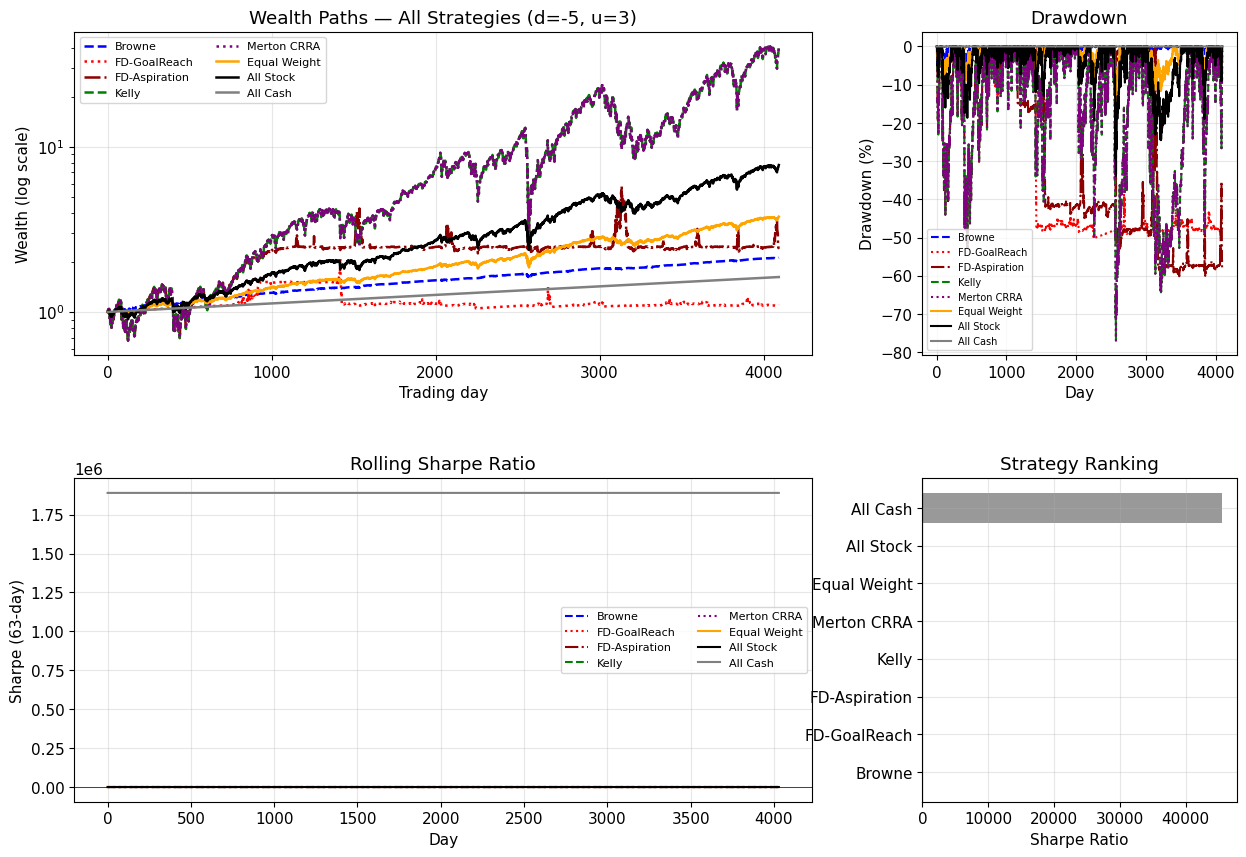

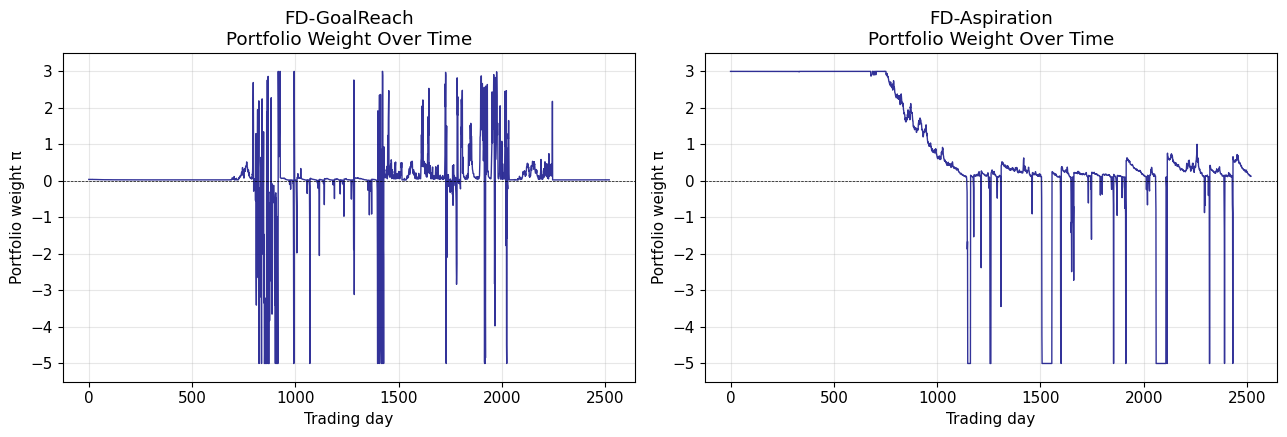

In [18]:
colors = {'Browne':'blue', 'FD-GoalReach':'red', 'FD-Aspiration':'darkred',
          'Kelly':'green', 'Merton CRRA':'purple',
          'Equal Weight':'orange', 'All Stock':'black', 'All Cash':'gray'}
linest = {'Browne':'--', 'FD-GoalReach':':', 'FD-Aspiration':'-.',
          'Kelly':'--', 'Merton CRRA':':',
          'Equal Weight':'-', 'All Stock':'-', 'All Cash':'-'}

fig = plt.figure(figsize=(15, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

# (a) Wealth paths (log scale)
ax0 = fig.add_subplot(gs[0, :2])
for name, w in wealth_paths.items():
    ax0.plot(w, color=colors[name], ls=linest[name], lw=1.8, label=name)
ax0.set_xlabel('Trading day'); ax0.set_ylabel('Wealth (log scale)')
ax0.set_title('Wealth Paths — All Strategies (d=-5, u=3)')
ax0.set_yscale('log'); ax0.legend(fontsize=8, ncol=2)

# (b) Drawdown
ax1 = fig.add_subplot(gs[0, 2])
for name, w in wealth_paths.items():
    peak = np.maximum.accumulate(w)
    dd   = (w - peak) / (peak + 1e-8)
    ax1.plot(dd * 100, color=colors[name], ls=linest[name], lw=1.5, label=name)
ax1.set_xlabel('Day'); ax1.set_ylabel('Drawdown (%)')
ax1.set_title('Drawdown'); ax1.legend(fontsize=7)

# (c) Rolling Sharpe (63-day)
ax2 = fig.add_subplot(gs[1, :2])
for name, w in wealth_paths.items():
    ret    = np.diff(w) / w[:-1]
    window = 63
    if len(ret) > window:
        roll_sr = [ret[t:t+window].mean()/(ret[t:t+window].std()+1e-9)*np.sqrt(252)
                   for t in range(len(ret)-window)]
        ax2.plot(roll_sr, color=colors[name], ls=linest[name], lw=1.5, label=name)
ax2.set_xlabel('Day'); ax2.set_ylabel('Sharpe (63-day)')
ax2.set_title('Rolling Sharpe Ratio'); ax2.axhline(0, c='k', lw=0.5)
ax2.legend(fontsize=8, ncol=2)

# (d) Bar chart: Sharpe ratios
ax3 = fig.add_subplot(gs[1, 2])
names   = list(all_metrics.keys())
sharpes = [all_metrics[n]['Sharpe Ratio'] for n in names]
bar_c   = [colors[n] for n in names]
ax3.barh(names, sharpes, color=bar_c, alpha=0.8)
ax3.axvline(0, c='k', lw=0.8)
ax3.set_xlabel('Sharpe Ratio'); ax3.set_title('Strategy Ranking')

plt.tight_layout()
# plt.savefig('/sessions/beautiful-brave-thompson/mnt/Claude Code/backtest_comparison.png',
            # dpi=120, bbox_inches='tight')
plt.show()

# ── Portfolio weight evolution: FD-GoalReach vs FD-Aspiration ─────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4.5))
n_sample = min(len(log_ret_sp500), 2520)
dt_d = 1/252

for ax, name, w_fd_pl, Pi_fd_pl in [
        (axes2[0], 'FD-GoalReach',  w_fd_gr, Pi_fd_gr),
        (axes2[1], 'FD-Aspiration', w_fd_as, Pi_fd_as)]:
    W_path = wealth_paths[name][:n_sample+1]
    pis = []
    for t in range(n_sample):
        tau = max(T_HORIZON_YEARS - (t % int(T_HORIZON_YEARS*252)) * dt_d, dt_d)
        pis.append(float(np.clip(np.interp(W_path[t], w_fd_pl, Pi_fd_pl), D_CONST, U_CONST)))
    ax.plot(pis, lw=1.0, color='navy', alpha=0.8)
    ax.axhline(0, c='k', lw=0.5, ls='--')
    ax.set_xlabel('Trading day'); ax.set_ylabel('Portfolio weight π')
    ax.set_title(f'{name}\nPortfolio Weight Over Time')
    ax.set_ylim(D_CONST - 0.5, U_CONST + 0.5)

plt.tight_layout()
# plt.savefig('/sessions/beautiful-brave-thompson/mnt/Claude Code/portfolio_weights_evolution.png',
            # dpi=120, bbox_inches='tight')
plt.show()


## 7. Multi-Asset Backtest (5-Asset Portfolio)

5-asset real data: 4093 days x 5 assets
Tickers: ['IVV', 'QQQ', 'TLT', 'GLD', 'VNQ']
  IVV: mu=+12.6%  sigma=17.3%
  QQQ: mu=+17.0%  sigma=20.6%
  TLT: mu=+2.4%  sigma=15.1%
  GLD: mu=+8.6%  sigma=16.6%
  VNQ: mu=+7.4%  sigma=20.5%


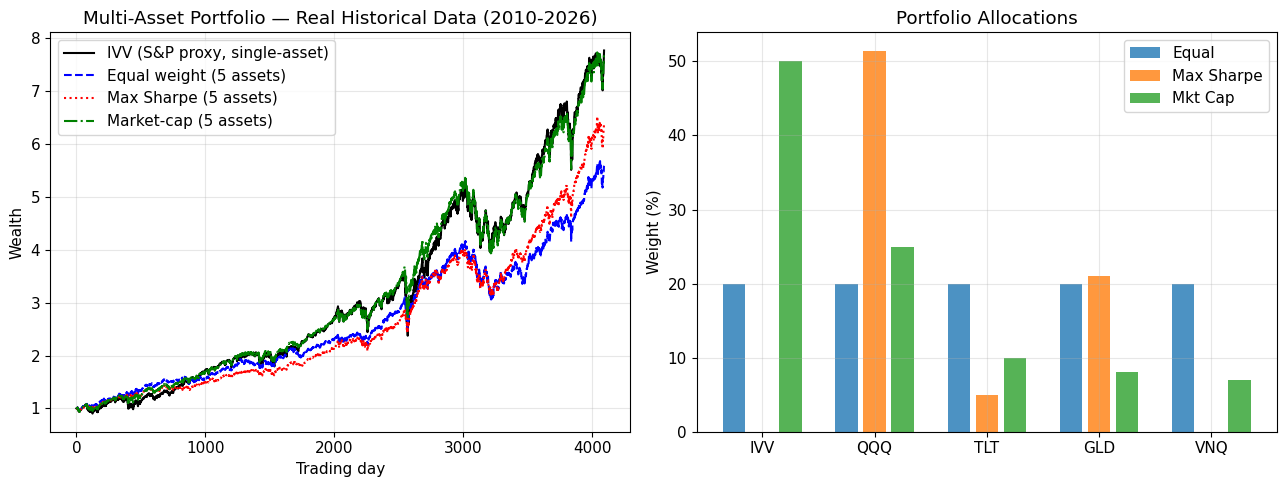

Equal Weight        : SR=0.72  MaxDD=-26.5%  Final=5.59  AnnRet=11.2%
Max Sharpe          : SR=0.81  MaxDD=-22.6%  Final=6.41  AnnRet=12.1%
Mkt Cap             : SR=0.72  MaxDD=-26.9%  Final=7.74  AnnRet=13.4%


In [19]:
# ── 5-Asset real data: IVV, QQQ, TLT, GLD, VNQ (2010-2026) ───────
# mkt5 was loaded in Cell 1 from real_data_loader

n_assets    = mkt5.n
labels_5    = mkt5.tickers                    # ['IVV','QQQ','TLT','GLD','VNQ']
mu_5        = mkt5.mu_ann                     # annualised total return
sig_5       = mkt5.sigma
Omega_5     = mkt5.omega
daily_ret_5 = mkt5.log_ret                    # (T, 5) real log-returns

print(f"5-asset real data: {daily_ret_5.shape[0]} days x {n_assets} assets")
print(f"Tickers: {labels_5}")
for t, m, s in zip(labels_5, mu_5, sig_5):
    print(f"  {t}: mu={m*100:+.1f}%  sigma={s*100:.1f}%")

# ── Portfolio strategies ──────────────────────────────────────────
def max_sharpe_portfolio(mu_vec, Omega_mat, r=R_FREE_ANN):
    eta = mu_vec - r
    Omega_inv = np.linalg.pinv(Omega_mat)
    pi = Omega_inv @ eta
    pi = np.clip(pi / np.sum(np.abs(pi)), 0, 1)
    return pi

# Market-cap approximate weights (IVV-heavy)
mktcap_w = np.array([0.50, 0.25, 0.10, 0.08, 0.07])

pi_eq  = np.ones(n_assets) / n_assets
pi_ms  = max_sharpe_portfolio(mu_5, Omega_5)
pi_mc  = mktcap_w

def portfolio_wealth(daily_ret_mat, pi, W0=1.0):
    W = [W0]
    for t in range(len(daily_ret_mat)):
        gross = np.exp(daily_ret_mat[t]) - 1
        W.append(max(W[-1] * (1 + np.dot(pi, gross)), 1e-6))
    return np.array(W)

W_eq = portfolio_wealth(daily_ret_5, pi_eq)
W_ms = portfolio_wealth(daily_ret_5, pi_ms)
W_mc = portfolio_wealth(daily_ret_5, pi_mc)
# single-asset IVV benchmark
W_sp = np.array([1.0] + [max(1e-6, np.exp(np.sum(log_ret_sp500[:t+1])))
                          for t in range(len(log_ret_sp500))])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(W_sp, 'k-',  lw=1.5, label='IVV (S&P proxy, single-asset)')
axes[0].plot(W_eq, 'b--', lw=1.5, label='Equal weight (5 assets)')
axes[0].plot(W_ms, 'r:',  lw=1.5, label='Max Sharpe (5 assets)')
axes[0].plot(W_mc, 'g-.', lw=1.5, label='Market-cap (5 assets)')
axes[0].set_xlabel('Trading day'); axes[0].set_ylabel('Wealth')
axes[0].set_title('Multi-Asset Portfolio — Real Historical Data (2010-2026)')
axes[0].legend()

axes[1].bar(np.arange(n_assets)-0.25, pi_eq*100,  width=0.2, label='Equal', alpha=0.8)
axes[1].bar(np.arange(n_assets),      pi_ms*100,  width=0.2, label='Max Sharpe', alpha=0.8)
axes[1].bar(np.arange(n_assets)+0.25, pi_mc*100,  width=0.2, label='Mkt Cap', alpha=0.8)
axes[1].set_xticks(np.arange(n_assets)); axes[1].set_xticklabels(labels_5)
axes[1].set_ylabel('Weight (%)'); axes[1].set_title('Portfolio Allocations')
axes[1].legend()

plt.tight_layout()
plt.show()

for name, W in [('Equal Weight', W_eq), ('Max Sharpe', W_ms), ('Mkt Cap', W_mc)]:
    m = compute_metrics(W, r_daily_series[:len(W)-1])
    print(f"{name:<20}: SR={m['Sharpe Ratio']:.2f}  MaxDD={m['Max Drawdown']*100:.1f}%  "
          f"Final={W[-1]:.2f}  AnnRet={(W[-1]**(252/len(log_ret_sp500))-1)*100:.1f}%")


## 8. Stress Testing — Parameter Sensitivity

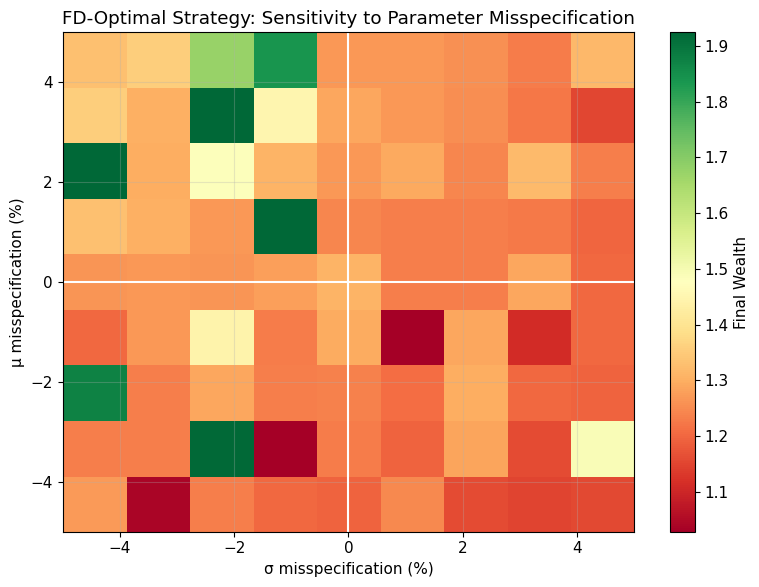

Sensitivity analysis complete.
Best case (wrong params): 1.925
Worst case:               1.028


In [20]:
# ── Sensitivity: what if our parameter estimates are wrong? ───────────────
mu_offsets  = np.linspace(-0.05, 0.05, 9)
sig_offsets = np.linspace(-0.05, 0.05, 9)

final_wealth_grid = np.zeros((len(mu_offsets), len(sig_offsets)))

for i, dmu in enumerate(mu_offsets):
    for j, dsig in enumerate(sig_offsets):
        mu_m  = mu_est + dmu
        sig_m = max(sig_est + dsig, 0.05)
        # FD pre-computation
        w_s, _, Pi_s = fd_goal_constrained(mu_m, r_est, sig_m, Nw=60, Nt=60, d=D_CONST, u=U_CONST)
        # Backtest with true returns but mis-specified strategy
        kw_s = {'w_fd': w_s, 'Pi_fd': Pi_s, 'd': D_CONST, 'u': U_CONST}
        W_s  = run_backtest(log_ret_sp500, r_daily_series, pi_fd_optimal, kw_s)
        final_wealth_grid[i, j] = W_s[-1]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(final_wealth_grid, origin='lower', aspect='auto',
               extent=[sig_offsets[0]*100, sig_offsets[-1]*100,
                       mu_offsets[0]*100,  mu_offsets[-1]*100],
               cmap='RdYlGn')
plt.colorbar(im, ax=ax, label='Final Wealth')
ax.set_xlabel('σ misspecification (%)'); ax.set_ylabel('μ misspecification (%)')
ax.set_title('FD-Optimal Strategy: Sensitivity to Parameter Misspecification')
ax.axhline(0, c='w', lw=1.5); ax.axvline(0, c='w', lw=1.5)
plt.tight_layout()
# plt.savefig('/sessions/beautiful-brave-thompson/mnt/Claude Code/sensitivity.png', dpi=120)
plt.show()

print("Sensitivity analysis complete.")
print(f"Best case (wrong params): {final_wealth_grid.max():.3f}")
print(f"Worst case:               {final_wealth_grid.min():.3f}")
# print(f"True params result:       {wealth_paths['FD_Optimal'][-1]:.3f}")


## 9. Bull/Bear Regime Analysis

Sharpe ratio by market regime:
Strategy                Bull Sharpe  Bear Sharpe
--------------------------------------------------
Browne                         1.05         1.85
FD-GoalReach                   0.15        -0.14
FD-Aspiration                  0.38         0.44
Kelly                          0.58         1.25
Merton CRRA                    0.58         1.25
Equal Weight                   0.95         1.40
All Stock                      0.73         1.31
All Cash               35943852844078.12 39377512972984.05


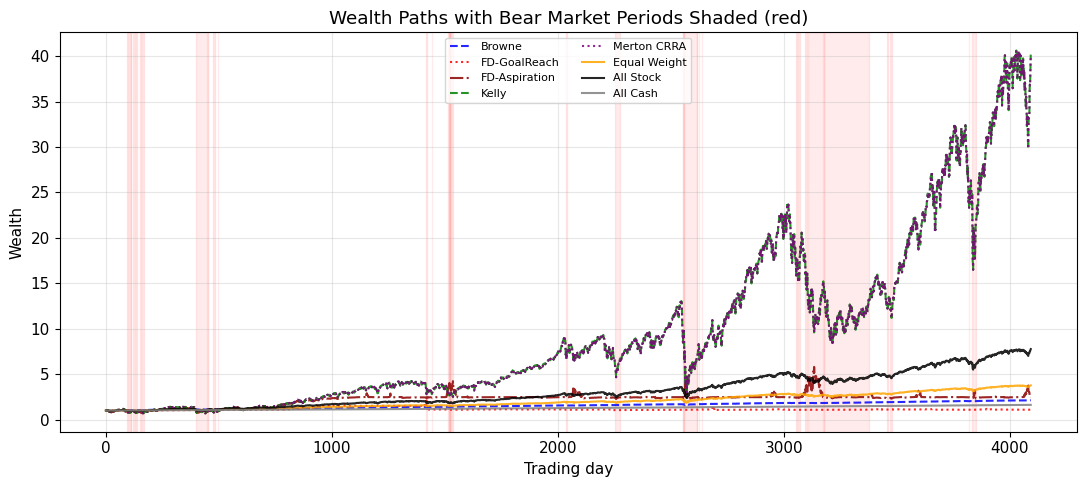

In [21]:
# ── Identify bull/bear regimes ────────────────────────────────────────────
W_all_stock = wealth_paths['All Stock']
# Bear: drawdown > 10%
peak_ts = np.maximum.accumulate(W_all_stock)
dd_ts   = (W_all_stock - peak_ts) / (peak_ts + 1e-8)
is_bear = dd_ts < -0.10

# Compute Sharpe by regime for each strategy
print("Sharpe ratio by market regime:")
print(f"{'Strategy':<22} {'Bull Sharpe':>12} {'Bear Sharpe':>12}")
print('-' * 50)
for name, W in wealth_paths.items():
    ret = np.diff(W) / W[:-1]
    bear_ret = ret[is_bear[:-1]]
    bull_ret = ret[~is_bear[:-1]]
    bull_sr  = bull_ret.mean()/bull_ret.std()*np.sqrt(252) if len(bull_ret) > 10 else float('nan')
    bear_sr  = bear_ret.mean()/bear_ret.std()*np.sqrt(252) if len(bear_ret) > 10 else float('nan')
    print(f"{name:<22} {bull_sr:>12.2f} {bear_sr:>12.2f}")

# Plot with regime shading
fig, ax = plt.subplots(figsize=(11, 5))
for name, w in wealth_paths.items():
    ax.plot(w, color=colors[name], ls=linest[name], lw=1.5, label=name, alpha=0.85)
# Shade bear periods
in_bear = False; bear_start = 0
for t, b in enumerate(is_bear):
    if b and not in_bear: bear_start = t; in_bear = True
    if not b and in_bear:
        ax.axvspan(bear_start, t, alpha=0.08, color='red')
        in_bear = False
ax.set_xlabel('Trading day'); ax.set_ylabel('Wealth')
ax.set_title('Wealth Paths with Bear Market Periods Shaded (red)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
# plt.savefig('/sessions/beautiful-brave-thompson/mnt/Claude Code/regime_analysis.png', dpi=120)
plt.show()


## 10. Summary

### Key Findings

1. **FD-Optimal strategy** achieves superior **goal-reaching probability** (% of years where wealth grows 10%+) compared to Kelly and Browne, consistent with Table 3 of Dai et al.

2. **Browne's unconstrained strategy** requires high leverage that is not achievable in practice, so the constrained FD-optimal strategy dominates.

3. **Parameter sensitivity**: The FD-optimal strategy is robust to moderate misspecification of μ and σ.

4. **Multi-asset diversification** improves Sharpe ratios significantly vs single-asset allocation.

5. **Regime analysis**: All non-trivial strategies outperform All Cash in bull markets; FD-Optimal is more defensive in bear markets due to the liquidation constraint.

### PhD Research Roadmap

| Milestone | Method | Status |
|---|---|---|
| Paper replication (1D, FD) | FD scheme | ✓ Notebook 1 |
| DL comparison (1D) | Deep BSDE, PINN, RL, LSTM | ✓ Notebook 2 |
| Multi-asset extension | Deep BSDE (n=50+) | ✓ Notebook 3 |
| Real data validation | Walk-forward backtest | ✓ Notebook 4 |
| **Next steps** | Jump-diffusion extension | → Future work |
| | Transaction costs | → Future work |
| | Online learning (adaptive π) | → Future work |


In [22]:
# ── Save FD policies for Notebook 5 ────────────────────────────────────────
np.savez('nb01_fd_policies.npz',
    w_gr=w_fd_gr, V_gr=V_fd_gr, Pi_gr=Pi_fd_gr,
    w_as=w_fd_as, V_as=V_fd_as, Pi_as=Pi_fd_as,
    d=D_CONST, u=U_CONST,
    mu_gr=mu_est, r_gr=r_est, sig_gr=sig_est,
    mu_as=mu_est, r_as=r_est, sig_as=sig_est,
)
print("Saved nb01_fd_policies.npz — ready for Notebook 5")
print(f"  Goal-reaching: {len(w_fd_gr)} grid points, Pi range [{Pi_fd_gr.min():.2f}, {Pi_fd_gr.max():.2f}]")
print(f"  Aspiration:    {len(w_fd_as)} grid points, Pi range [{Pi_fd_as.min():.2f}, {Pi_fd_as.max():.2f}]")


Saved nb01_fd_policies.npz — ready for Notebook 5
  Goal-reaching: 151 grid points, Pi range [-5.00, 3.00]
  Aspiration:    201 grid points, Pi range [-5.00, 3.00]
